# Logistic Regression by hand

In [ ]:
import torch
import torch.nn.functional as F
# [hours_studied, attendance]
X = torch.tensor([ [1.0, 50.0], [2.0, 55.0], [2.5, 60.0], [3.0, 65.0], [3.5, 70.0], [4.0, 72.0], [5.0, 80.0], [6.0, 85.0], [7.0, 90.0], [8.0, 95.0] ])
y = torch.tensor([ [0.0], [0.0], [0.0], [0.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0] ])
print(X.shape)  # torch.Size([10, 2])
print(y.shape)  # torch.Size([10, 1])

torch.Size([10, 2])
torch.Size([10, 1])


In [ ]:
torch.manual_seed(42)
w = torch.randn((2, 1)); w.requires_grad=True
b = torch.randn(1); b.requires_grad=True

In [ ]:
# helper functions

def hypothesis(X):
  h = X @ w + b
  return h

def softplus(h, beta=1.0, threshold=20):
  # unstable x
  bh = beta * h
  mask = bh > threshold
  safe = bh.clamp(max=threshold)
  stable = torch.log1p(safe.exp())/beta
  # numerically stable x
  return torch.where(mask, h, stable)


def log_likelihood(h, y, soft):
  # return (y * g.log() + (1-y)* (1-g).log()).mean()
  return (h * y - soft).mean()

def evaluation()

In [ ]:
lossi = []

In [ ]:
# Neural Network Training
for i in range(10000):
  # Forward pass
  h = hypothesis(X)
  soft = softplus(h)
  loss = log_likelihood(h, y, soft)

  # Backward pass
  w.grad = None; b.grad = None
  loss.backward()

  # Update parameters
  with torch.no_grad():
    w += 0.01 * w.grad
    b += 0.01 * b.grad
  if i%1000 == 0:
    print(f"{i/1000}: Loss -> {loss}")
  lossi.append(loss.item())

0.0: Loss -> -0.06529071182012558
1.0: Loss -> -0.06438814103603363
2.0: Loss -> -0.06351885944604874
3.0: Loss -> -0.06268028169870377
4.0: Loss -> -0.06187092512845993
5.0: Loss -> -0.0610881932079792
6.0: Loss -> -0.06033188849687576
7.0: Loss -> -0.0595991313457489
8.0: Loss -> -0.05888902023434639
9.0: Loss -> -0.058201152831315994


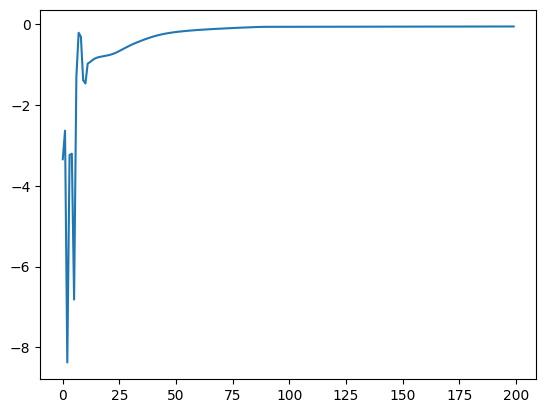

In [ ]:
import matplotlib.pyplot as plt

plt.plot([lossi[i] for i in range(len(lossi)) if i%100 == 0])

In [ ]:
for a,b in zip(g, y):
  print(a, b)

tensor([0.4817], grad_fn=<UnbindBackward0>) tensor([0.])
tensor([0.5486], grad_fn=<UnbindBackward0>) tensor([0.])
tensor([0.5737], grad_fn=<UnbindBackward0>) tensor([0.])
tensor([0.5985], grad_fn=<UnbindBackward0>) tensor([0.])
tensor([0.6229], grad_fn=<UnbindBackward0>) tensor([1.])
tensor([0.6552], grad_fn=<UnbindBackward0>) tensor([1.])
tensor([0.7052], grad_fn=<UnbindBackward0>) tensor([1.])
tensor([0.7578], grad_fn=<UnbindBackward0>) tensor([1.])
tensor([0.8036], grad_fn=<UnbindBackward0>) tensor([1.])
tensor([0.8425], grad_fn=<UnbindBackward0>) tensor([1.])


# Logistic Regression by hand + torch apis

In [ ]:
import torch
import torch.nn.functional as F

torch.manual_seed(0)

# ---- original 10 points ----
X0 = torch.tensor([[1.0, 50.0], [2.0, 55.0], [2.5, 60.0], [3.0, 65.0], [3.5, 70.0],
                   [4.0, 72.0], [5.0, 80.0], [6.0, 85.0], [7.0, 90.0], [8.0, 95.0]])
y0 = torch.tensor([0., 0., 0., 0., 1., 1., 1., 1., 1., 1.])

# ---- 190 synthetic points with the same structure ----
M = 190
x1 = torch.rand(M) * 7 + 1                               # hours: 1..8
x2 = 50 + (x1 - 1) * (45 / 7) + torch.randn(M) * 5       # score, correlated with hours
Xs = torch.stack([x1, x2], dim=1)
ys = torch.bernoulli(torch.sigmoid(1.5 * (x1 - 3.3)))    # P(y=1) rises around 3.3 hours

X = torch.cat([X0, Xs])                                  # (200, 2)
y = torch.cat([y0, ys])                                  # (200,)  1-D, see note below

# ---- split ----
N = X.shape[0]
perm = torch.randperm(N)
n_tr = int(0.8 * N)
tr, te = perm[:n_tr], perm[n_tr:]

# standardize with TRAIN statistics only
mu, sd = X[tr].mean(0), X[tr].std(0)
Xtr, ytr = (X[tr] - mu) / sd, y[tr]
Xte, yte = (X[te] - mu) / sd, y[te]

print(Xtr.shape, Xte.shape, ytr.shape, yte.shape)

torch.Size([160, 2]) torch.Size([40, 2]) torch.Size([160]) torch.Size([40])


In [ ]:
!pip install lochan-eda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from lochan_eda import AutomatedEDA

eda = AutomatedEDA()

df = pd.read_csv("/content/bank.csv", sep=";")
df["y"] = df["y"].map({"no": 0, "yes": 1})
Xtr, Xte, ytr, yte = eda.prepare(df, target="y", stratify=df["y"])
Xtrnp = Xtr.to_numpy(dtype=np.float32); Xtenp = Xte.to_numpy(dtype=np.float32)
Xtr = torch.from_numpy(Xtrnp); Xte = torch.from_numpy(Xtenp)
ytrnp = ytr.to_numpy(dtype=np.float32); ytenp = yte.to_numpy(dtype=np.float32)
ytr = torch.from_numpy(ytrnp); yte = torch.from_numpy(ytenp)

In [ ]:
Xtr.shape, ytr.shape, Xte.shape, yte.shape

(torch.Size([3616, 22]),
 torch.Size([3616]),
 torch.Size([905, 22]),
 torch.Size([905]))

In [ ]:
(Xtr @ w + b).shape

torch.Size([3616, 1])

In [ ]:
# helper functions

# def hypothesis(X):
#   h = X @ w + b
#   return h

# def softplus(h, beta=1.0, threshold=20):
#   # unstable x
#   bh = beta * h
#   mask = bh > threshold
#   safe = bh.clamp(max=threshold)
#   stable = torch.log1p(safe.exp())/beta
#   # numerically stable x
#   return torch.where(mask, h, stable)

# is equavalent to F.softplus


def log_likelihood(h, y):
  # return (y * g.log() + (1-y)* (1-g).log()).mean()
  return (h * y - F.softplus(h)).mean()

@torch.no_grad()
def evaluation(X, y):
  h = hypothesis(X)
  ll = log_likelihood(h, y)
  acc = ((h > 0).float() == y).float().mean().item()
  return ll, acc

In [ ]:
lossi = []
val_ll = []
val_acc = []

# ---- params ----
w = torch.zeros(22, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [ ]:
lr = 0.01
epochs = 20000
optimizer = torch.optim.SGD((w, b), lr=lr, maximize=False)

for i in range(epochs):
  # Forward pass
  # logits = hypothesis(Xtr)
  logits = Xtr @ w + b
  # loss = log_likelihood(h, ytr)
  loss = F.binary_cross_entropy_with_logits(logits.squeeze(), ytr, reduction="mean")

  # Try with sigmoid (unstable - y/n? )
  # g = F.sigmoid(logits)
  # loss = F.binary_cross_entropy(g, ytr)

  # Backward pass
  # w.grad = None; b.grad = None
  optimizer.zero_grad()
  loss.backward()

  # Updating parameters
  # with torch.no_grad():
  #   w += lr * w.grad
  #   b += lr * b.grad
  optimizer.step()

  # Track the ll, acc
  lossi.append(loss.item())
  ll, acc = evaluation(Xte, yte)
  val_ll.append(ll)
  val_acc.append(acc)

  if i%10000 == 0 or i == 5 or i == epochs-1:
    print(f"Checkpoint {i/10000}: Loss: {loss.item()}, Val ll: {ll}, Val Acc: {acc}")

Checkpoint 0.0: Loss: 1.5022056102752686, Val ll: -1.049149990081787, Val Acc: 0.8382772207260132
Checkpoint 0.0005: Loss: 1.4474072456359863, Val ll: -1.0180574655532837, Val Acc: 0.8382772207260132


KeyboardInterrupt: 

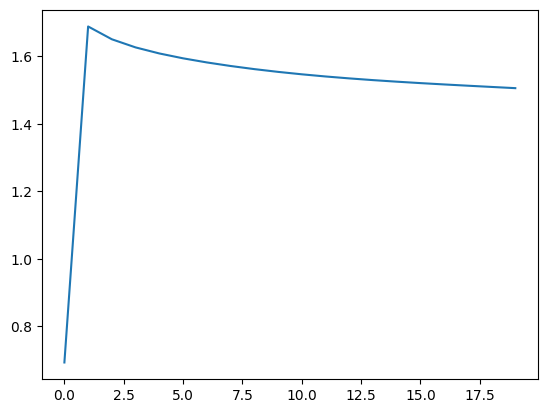

In [ ]:
import matplotlib.pyplot as plt
plt.plot([lossi[i] for i in range(len(lossi)) if i % 1000 == 0])

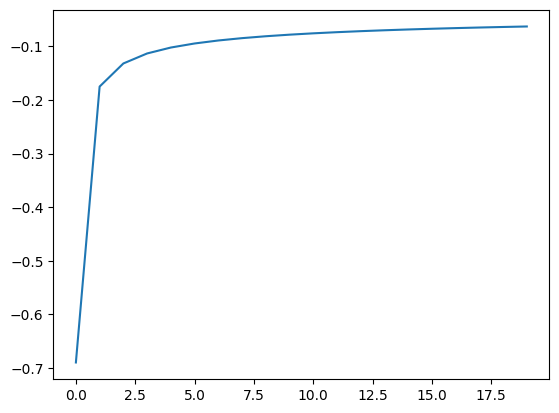

In [ ]:
plt.plot([val_ll[i] for i in range(len(val_ll)) if i % 1000 == 0])

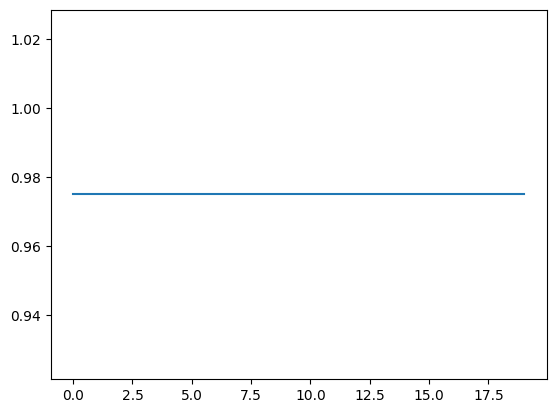

In [ ]:
plt.plot([val_acc[i] for i in range(len(val_acc)) if i % 1000 == 0])

In [ ]:
ll, acc = evaluation(Xte, yte)
print(ll, acc)

tensor(-0.4273) 0.8500000238418579


# Digression

In [ ]:
import torch

def make_linearly_separable(n=200, noise=0.0, seed=0):
    g = torch.Generator().manual_seed(seed)
    x1 = torch.rand(n, generator=g) * 7 + 1        # hours: 1..8
    true_boundary = 4.5
    y = (x1 > true_boundary).float()               # clean deterministic label
    x2 = 50 + (x1 - 1) * (45 / 7)                   # clean linear trend
    x1n = x1 + torch.randn(n, generator=g) * noise
    x2n = x2 + torch.randn(n, generator=g) * noise * 5
    X = torch.stack([x1n, x2n], dim=1)
    return X, y

torch.manual_seed(0)
X, y = make_linearly_separable(n=200, noise=0.35, seed=0)   # try 0.0 / 0.8 / 1.5 for other ceilings

N = X.shape[0]
perm = torch.randperm(N)
n_tr = int(0.8 * N)
tr, te = perm[:n_tr], perm[n_tr:]

mu, sd = X[tr].mean(0), X[tr].std(0)
Xtr, ytr = (X[tr] - mu) / sd, y[tr]
Xte, yte = (X[te] - mu) / sd, y[te]

print(Xtr.shape, Xte.shape, ytr.shape, yte.shape)
print("train class balance:", ytr.mean().item())

torch.Size([160, 2]) torch.Size([40, 2]) torch.Size([160]) torch.Size([40])
train class balance: 0.48750001192092896


In [ ]:
class Digression:
  def __init__(self):
    self.w = torch.randn((2, 1), requires_grad=True)
    self.b = torch.randn(1, requires_grad=True)
    self.lossi = []

  def hypothesis(self, X):
    logits = X @ self.w + self.b
    return torch.where(logits >= 0, 1, 0)

  def evaluate(self, X, y):
    h = self.hypothesis(X)
    acc = (h == y).float().mean() * 100
    return acc

  def lossi_plot(self):
    import matplotlib.pyplot as plt
    step = int(self.epochs/10)
    plotting_lossi = [sum(model.lossi[i: i+step])/step   for i in range(len(model.lossi)) if i%step == 0]
    plt.plot(plotting_lossi)
    plt.show()

  def fit(self, X, y, lr=0.01, epochs=100):
    self.lr = lr
    self.epochs = epochs
    for i in range(epochs):
      misclassifications = 0
      for xi, yi in zip(X, y):
        hi = self.hypothesis(xi.unsqueeze(0))
        if hi != yi:
          with torch.no_grad():
            self.w += lr * (yi.reshape(1,1) - hi) * xi.reshape(2, 1)
            self.b += lr * (yi - hi.squeeze())
          misclassifications += 1
      self.lossi.append(misclassifications)

In [ ]:
model = Digression()

In [ ]:
model.fit(Xtr, ytr, lr=0.1, epochs=10000)

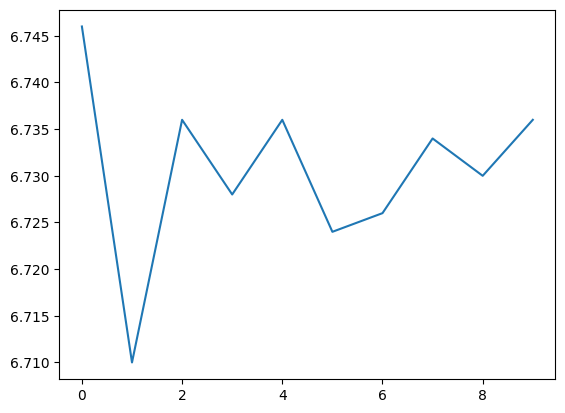

In [ ]:
model.lossi_plot()

# Multi Class Classification


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)

X = torch.from_numpy(X); X = X.to(torch.float32)
y = torch.from_numpy(y); y = y.to(torch.int64)

Xtr, Xte, ytr, yte = train_test_split( X, y, test_size=0.2, random_state=32423432, stratify=y )

In [ ]:
# torch.unique(ytr) # 0, 1, 2 -> We have 3 classes
# Xtr.shape # [120, 4] -> We have 4 features

In [ ]:
# 120, 3 ->

In [ ]:
class LogisticRegression:
  def __init__(self):
    self.w = torch.randn(4, 3, requires_grad=True)
    self.b = torch.randn(3, requires_grad=True)

  def hypothesis(self, X):
    return X @ self.w + self.b

  def softmax(self, logits):
    return logits.exp()/logits.exp().sum(1, keepdim=True)

  def evaluate(self, X, y):
    logits = self.hypothesis(X)
    probs = self.softmax(logits)
    predicts = probs.argmax(dim=1)
    return (predicts == y).float().mean()

  def fit(self, X, y, lr=0.1, epochs=500):
    for i in range(epochs):
      # Forward pass
      logits = self.hypothesis(X)
      # probs = self.softmax(logits)
      # log_likelihood = probs[torch.arange(0, len(y)), y].log().mean()
      log_likelihood = F.cross_entropy(logits, y)
      # Backwrad pass
      self.w.grad = None; self.b.grad = None
      log_likelihood.backward()

      # update the parameters
      with torch.no_grad():
        self.w += - 0.1 * self.w.grad
        self.b += - 0.1 * self.b.grad

      if i%(epochs/10) == 0:
        print(f"chkpt {i/(epochs/10)}: Loss {log_likelihood}")


In [ ]:
model = LogisticRegression()
model.fit(Xtr, ytr)

chkpt 0.0: Loss 6.638079643249512
chkpt 1.0: Loss 0.5341129302978516
chkpt 2.0: Loss 0.3949488401412964
chkpt 3.0: Loss 0.2984095811843872
chkpt 4.0: Loss 0.2627732753753662
chkpt 5.0: Loss 0.23936839401721954
chkpt 6.0: Loss 0.2210671454668045
chkpt 7.0: Loss 0.20636646449565887
chkpt 8.0: Loss 0.19430163502693176
chkpt 9.0: Loss 0.18422254920005798


In [ ]:
model.evaluate(Xte, yte), model.evaluate(Xtr, ytr)

(tensor(1.), tensor(0.9667))

# with Newtons method

In [ ]:
import torch
import torch.nn.functional as F

class NewtonMultinomialLogisticRegression:
    def __init__(self, n_features, n_classes):
        self.d = n_features + 1          # +1 for bias, folded into theta
        self.K = n_classes
        self.theta = torch.zeros(self.d, self.K, requires_grad=True)   # (d+1, K)
        self.lossi = []

    @staticmethod
    def add_bias(X):
        ones = torch.ones(X.shape[0], 1)
        return torch.cat([X, ones], dim=1)

    def hypothesis(self, X_aug):
        return X_aug @ self.theta                   # (N, K) raw logits

    def evaluate(self, X, y):
        X_aug = self.add_bias(X)
        logits = self.hypothesis(X_aug)
        preds = logits.argmax(dim=1)                 # no softmax needed, argmax is monotonic
        return (preds == y).float().mean().item()

    def fit(self, X, y, epochs=10, verbose=True):

      X = self.add_bias(X)

      for epoch in range(epochs):

          logits = self.hypothesis(X)

          log_probs = F.log_softmax(logits, dim=1)

          ll = log_probs[
              torch.arange(X.shape[0]),
              y
          ].mean()

          loss = -ll


          grad = torch.autograd.grad(
              loss,
              self.theta,
              create_graph=True
          )[0]

          # (5, 3) -> (15,)
          g = grad.reshape(-1)

          H_rows = []

          for j in range(g.numel()):

              h = torch.autograd.grad(
                  g[j],
                  self.theta,
                  retain_graph=True
              )[0]

              H_rows.append(h.reshape(-1))

          H = torch.stack(H_rows)

          delta = torch.linalg.solve(H, g)

          with torch.no_grad():
              self.theta -= delta.reshape_as(self.theta)

          self.theta.requires_grad_()

          self.lossi.append(loss.item())

          if verbose:
              print(f"epoch {epoch}: loss = {loss.item():.6f}")

In [ ]:
model = NewtonMultinomialLogisticRegression(n_features=4, n_classes=3)
model.fit(Xtr, ytr, epochs=10)

epoch 0: loss = 1.098612
epoch 1: loss = 0.479495
epoch 2: loss = 0.320574
epoch 3: loss = 0.164202
epoch 4: loss = 0.094269
epoch 5: loss = 0.065491
epoch 6: loss = 0.052929
epoch 7: loss = 0.047562
epoch 8: loss = 0.045782
epoch 9: loss = 0.045458


In [ ]:
model.evaluate(Xte, yte)

1.0

In [ ]:
logits = Xtr @ w + b
probs = logits.exp()/logits.exp().sum(dim=1, keepdim=True)
ll = probs[range(Xtr.shape[0]), ytr].log().mean()
loss = -ll

In [ ]:
theta = torch.cat([w.reshape(-1), b])

In [ ]:
gw, gb = torch.autograd.grad(loss, (w, b), create_graph=True)

In [ ]:
g = torch.cat([gw.reshape(-1), gb]) # gradient

In [ ]:
H_rows = []
for gi in g:
  row = torch.autograd.grad(
      gi,
      (w, b),
      retain_graph=True
  )
  hw, hb = row
  H_rows.append(
      torch.cat([hw.reshape(-1), hb])
  )

In [ ]:
H = torch.stack(H_rows) # -> He

In [ ]:
delta = torch.linalg.solve(H, g)
theta = theta - delta

In [ ]:
ex = torch.randn(2, 2)

In [ ]:
ex

tensor([[ 2.4454,  0.2861],
        [ 0.3503, -1.6769]])

tensor([[[ 2.4454,  0.2861],
         [ 0.3503, -1.6769]],

        [[ 2.4454,  0.2861],
         [ 0.3503, -1.6769]]])

## torch 1

In [ ]:
Xtr.shape, ytr.shape, Xte.shape, yte.shape

(torch.Size([160, 2]),
 torch.Size([160]),
 torch.Size([40, 2]),
 torch.Size([40]))

In [ ]:
linear = torch.nn.Linear(2, 1, bias=True)
sigmoid = torch.nn.Sigmoid()
loss = torch.nn.BCELoss()
loss_with_logits = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=linear.parameters(), lr=0.01, maximize=False)
epochs = 10000
lossi = []

In [ ]:
for i in range(epochs):
  # Forward Pass
  logits = linear(Xtr)
  # h = sigmoid(logits)
  # nll = loss(h, ytr.unsqueeze(dim=1))
  nll = loss_with_logits(logits, ytr.unsqueeze(dim=1))

  # Backward Pass
  optimizer.zero_grad()
  nll.backward()

  # update parameters
  optimizer.step()
  lossi.append(nll.item())

Text(0.5, 1.0, '0.34919536113739014')

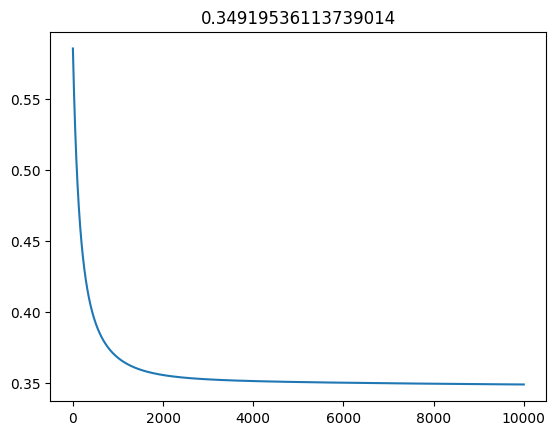

In [ ]:
import matplotlib.pyplot as plt
plt.plot(lossi)
plt.title(lossi[-1])